Here we start to Shitify!!

In [ ]:
!pip install tensorflow librosa pretty_midi pandas numpy

# Generates a .json file to work as an index

In [ ]:
import pandas as pd
import json
from pathlib import Path

# Load metadata
meta_path = next(Path("maestro-v3.0.0-mp3").glob("*.json"))
with open(meta_path) as f:
    meta = json.load(f)

df = pd.DataFrame(meta)
print(df.columns.tolist())
print(df.head())
print(f"\nTotal files: {len(df)}")
print(f"Splits: {df['split'].value_counts().to_dict()}")

In [ ]:
print(df["audio_filename"].iloc[0])
print(df["midi_filename"].iloc[0])

# Transforms .wav files to mp3

In [ ]:
from pathlib import Path

# Patch audio filenames from .wav to .mp3
df['audio_filename'] = df['audio_filename'].str.replace('.wav', '.mp3', regex=False)

# Verify the files actually exist
missing = [f for f in df['audio_filename'] if not (Path("maestro-v3.0.0-mp3") / f).exists()]
print(f"Missing files: {len(missing)} / {len(df)}")
print(df['audio_filename'].iloc[0])

In [ ]:
df

# Pipeline

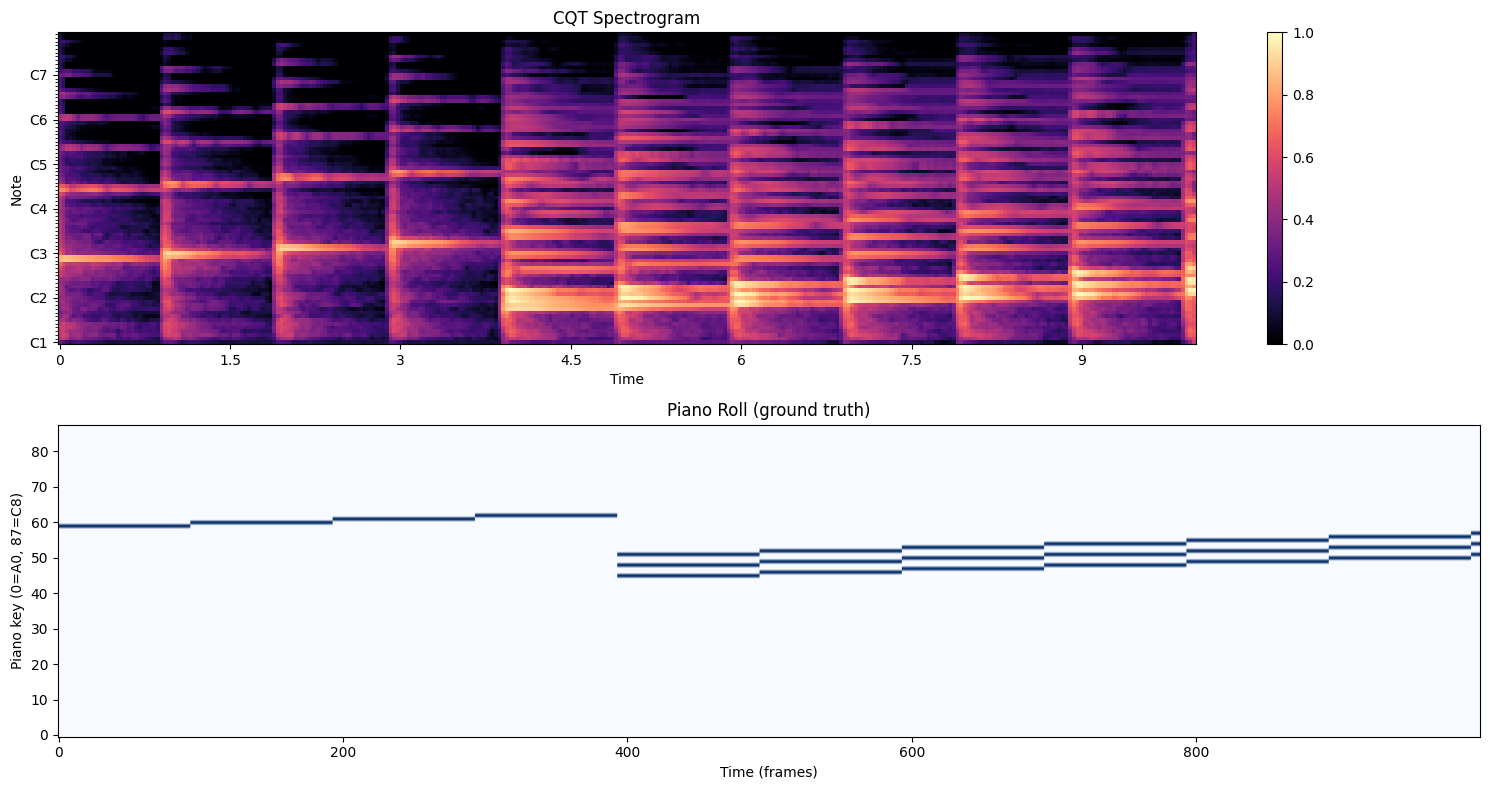

In [ ]:
from maestro_pipeline_CQT import MAESTRODataLoader, CQTPreprocessor
from poms_pipeline2 import MELPreprocessor
import matplotlib.pyplot as plt
import librosa.display

loader = MAESTRODataLoader("./maestro-v3.0.0-mp3")
# pairs = loader.get_pairs(split="train")
pairs = [{'audio_path': 'midi.mp3',
  'midi_path': 'midi.mid',
  'duration': 26}]
audio, piano_roll = loader.load_pair(pairs[0])

# preprocessor = CQTPreprocessor
preprocessor = MELPreprocessor()
# cqt = preprocessor.compute(audio)
mel = preprocessor.compute_mel(audio)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].set_title("CQT Spectrogram")
librosa.display.specshow(mel[:, :, 0], sr=16000, hop_length=512, x_axis="time", y_axis="cqt_note", ax=axes[0])
plt.colorbar(axes[0].collections[0], ax=axes[0])

axes[1].set_title("Piano Roll (ground truth)")
axes[1].imshow(piano_roll, aspect="auto", origin="lower", cmap="Blues")
axes[1].set_xlabel("Time (frames)")
axes[1].set_ylabel("Piano key (0=A0, 87=C8)")

plt.tight_layout()
plt.show()

In [ ]:
piano_roll

# Model

In [2]:
import tensorflow as tf

def build_model(n_bins=84, n_frames=313, n_keys=88, n_time=1000):
    inputs = tf.keras.Input(shape=(n_bins, n_frames, 1))

    # CNN Block
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Reshape for Transformer
    x = tf.keras.layers.Reshape((-1, x.shape[-1]))(x)

    # Transformer Block
    x = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Output → (88 * 1000) then reshape to (88, 1000)
    x = tf.keras.layers.Dense(n_keys * n_time)(x)       # 88000
    x = tf.keras.layers.Reshape((n_keys, n_time))(x)    # (88, 1000)
    outputs = tf.keras.layers.Activation('sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 84, 313,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 84, 313,   │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 84, 313,   │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 84, 313,   │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 313,   │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 42, 156,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 42, 156,   │          0 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 42, 156,   │    295,168 │ dropout[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 156,   │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 21, 78,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 21, 78,    │          0 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1638, 256) │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1638, 256) │    526,080 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1638, 256) │        512 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 88000)     │ 22,616,000 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 88, 1000)  │          0 │ dense[0][0]     

 Total params: 23,514,048 (89.70 MB)

 Trainable params: 23,513,152 (89.70 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from poms_pipeline2 import AudioPreprocessingPipeline

mel2 = AudioPreprocessingPipeline()

# train_ds = build_tf_dataset("./maestro-v3.0.0-mp3", split="train", batch_size=16)
# val_ds   = build_tf_dataset("./maestro-v3.0.0-mp3", split="validation", batch_size=16)

# Manually create pairs with your test files
pairs = [
    {
        "audio_path": "./maestro-v3.0.0-mp3/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.mp3",
        "midi_path":  "./maestro-v3.0.0-mp3/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi",
    }
]

mel, roll = mel2.load_pair(pairs[0]["audio_path"], pairs[0]["midi_path"])

import numpy as np
mel_input  = np.expand_dims(mel, axis=0)   # (1, 84, 313, 1)
roll_input = np.expand_dims(roll, axis=0)  # (1, 88, 1000)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    mel_input,
    roll_input,
    epochs=10
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 0.6941
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.0000e+00 - loss: 0.6897
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.0000e+00 - loss: 0.6251
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.0000e+00 - loss: 0.5594
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.0000e+00 - loss: 0.4934
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.0000e+00 - loss: 0.4609
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.0114 - loss: 0.4085
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.0000e+00 - loss: 0.3672
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.0000e+00 - loss: 0.3389
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.0227 - loss: 0.3180


# Transform numpy array to a df (not necessary)

In [ ]:
import pandas as pd

# Load a single pair
from maestro_pipeline_CQT import MAESTRODataLoader

loader = MAESTRODataLoader("./maestro-v3.0.0-mp3")
pairs = loader.get_pairs(split="train")
audio, piano_roll = loader.load_pair(pairs[0])

# Piano key names A0 to C8
import pretty_midi
key_names = [pretty_midi.note_number_to_name(i) for i in range(21, 109)]

# Convert to DataFrame
# Rows = 88 piano keys, Columns = 1000 time frames
df = pd.DataFrame(piano_roll, index=key_names)

print(df.shape)   # (88, 1000)
df

# Generates a CSV out of the "piano_roll" array
#### The CSV file is saved to the root folder

In [ ]:
import numpy as np

my_array = piano_roll

np.savetxt("piano_roll_output.csv", my_array, delimiter=",")

print("CSV saved successfully via NumPy!")

# Transforms the CSV into a .midi file

In [ ]:
import pandas as pd
import pretty_midi

def csv_to_midi(csv_path, output_midi_path, fs=50, threshold=0.5):
    """
    Converts an (88, T) piano roll CSV file into a standard MIDI file.

    Parameters:
    - csv_path: Path to your saved piano roll CSV file.
    - output_midi_path: The filename/path for the generated MIDI file.
    - fs: Sampling frequency (frames per second).
          e.g., fs=50 means each column represents 20 milliseconds.
    - threshold: Activation threshold for probabilities (0.0 to 1.0).
    """
    # 1. Load the CSV data (ignoring headers if they exist)
    df = pd.read_csv(csv_path, header=None)
    piano_roll_88 = df.values  # Shape: (88, Time)

    # 2. Transpose to (Time, 88) so we can iterate through time steps row-by-row
    piano_roll = piano_roll_88.T

    # 3. Initialize PrettyMIDI objects
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # 0 = Acoustic Grand Piano

    # Pad the matrix with an extra empty step at the end to catch any final note-offs
    padded_roll = np.pad(piano_roll, ((0, 1), (0, 0)), 'constant')
    active_notes = {}

    # 4. Parse time steps
    for step in range(padded_roll.shape[0]):
        current_time = step / fs

        for idx in range(88):
            midi_pitch = idx + 21  # Offset index by 21 (Key 0 maps to A0 / MIDI 21)
            activation_value = padded_roll[step, idx]
            is_note_active = activation_value > threshold

            # Case A: Note just turned on
            if is_note_active and midi_pitch not in active_notes:
                # Scale velocity back to full 0-127 MIDI range if it's a 0.0-1.0 probability
                velocity = int(activation_value * 127) if activation_value <= 1.0 else int(activation_value)
                velocity = max(min(velocity, 127), 1)  # Clamp between 1 and 127
                active_notes[midi_pitch] = (current_time, velocity)

            # Case B: Note just turned off
            elif not is_note_active and midi_pitch in active_notes:
                start_time, note_velocity = active_notes.pop(midi_pitch)

                # Append the completed note to our track
                note = pretty_midi.Note(
                    velocity=note_velocity,
                    pitch=midi_pitch,
                    start=start_time,
                    end=current_time
                )
                instrument.notes.append(note)

    # 5. Save the file
    pm.instruments.append(instrument)
    pm.write(output_midi_path)
    print(f"🎉 Success! MIDI file saved to: {output_midi_path}")

# --- Execute the script ---
csv_to_midi(
    csv_path='piano_roll_output.csv',
    output_midi_path='transcribed_song.mid',
    fs=100,          # Adjust this if your song plays back too fast or too slow!
    threshold=0.5   # Adjust if notes are missing or blending together too much
)

# Synthesizes a MIDI file into raw audio using basic mathematical sine waves.

In [ ]:
import os
from IPython.display import Audio, display

soundfont_file = "Grand.Piano.sf2"
midi_file = "midi.mid"
output_wav = "output.wav"

try:
    if os.path.exists(output_wav) and os.path.getsize(output_wav) > 0:
        display(Audio(filename=output_wav))

except Exception as e:
    print(f"❌ Script failed to execute: {e}")

In [ ]:
from maestro_pipeline_CQT import build_tf_dataset
from poms_pipeline import AudioPreprocessingPipeline

# CQT pipeline
cqt_ds = build_tf_dataset("./maestro-v3.0.0-mp3", split="train")

# Mel pipeline
mel_pipeline = AudioPreprocessingPipeline()
mel_ds = mel_pipeline.build_tf_dataset("./maestro-v3.0.0-mp3", split="train")

# Train two models and compare results
model_cqt.fit(cqt_ds, epochs=10)
model_mel.fit(mel_ds, epochs=10)